# <span style="color:darkblue"> Lecture 10d - Custom Predictive Model

<font size = "5">

In this example we will show how to construct a custom predictive <br>
model in Python, that involves training and prediction using Python classes.

Our goal will be to:

- Practice coding the regression coefficients manually
- Unpack some of the mechanics of classes and how they are used in "statsmodels"

# <span style="color:darkblue"> I. Set up working environment

<font size = "5">

Import relevant packages

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

<font size = "5">

Import Data

In [55]:
dataset = pd.read_stata("data_raw/malawiexperiment.dta")

<font size = "5">

Define $y$ and $X$ data

In [56]:
y = dataset["lit"]
X = dataset[["farmer","ave"]]

<font size = "5">

Regression packages often drop missing observations

In [57]:
valid_rows = X.notnull().all(axis=1) & y.notnull()

y = y[valid_rows]
X = X[valid_rows]

# <span style="color:darkblue"> II. OLS as a function

<font size = "5">

The ordinary least squares coefficients can be written <br>
in matrix form as

$ \widehat{\beta} = (W'W)^{-1}(W'y) $

where $W = [1,X] $ is a matrix that adds a column with ones to the matrix $X$ <br>
and $y$ is a vector stacking everybody's outcomes.

In [58]:
# Create formula for computing the OLS coefficients 
def compute_ols(X,y):
    # Count observations
    n = X.shape[0]

    # Conduct matrix operations
    W = np.c_[np.ones((n,1)), X] # Add column with ones
    Qww = W.T.dot(W)     # W'W
    Qwy = np.dot(W.T,y)  # W'y

    # Stores parameters as attributes
    beta = np.linalg.inv(Qww).dot(Qwy)

    # Return itself (this is important if you want to continue operations
    # over the same object)        
    return beta


<font size = "5">

Compute coefficients

In [60]:
compute_ols(X,y)


array([ 0.65109835, -0.04550724,  0.00086329])

# <span style="color:darkblue"> III. An object-oriented approach

<font size = 5>

In the example above, we were interested only in the coefficients. <br>
However, in practice statistical models often report and store many <br>
other intermediate diagnostics, which can be used for further tests. A <br>
common use-case:

- Estimate a basic model (operation 1)
- Make a prediction (operation 2)

For operation 2, we need intermedaite results from 1.<br>
How to store and retrieve the necessary information?

Python classes and instances!


# <span style="color:darkblue"> IV. OLS Example

<font size = "5">

Define a model class

In [68]:
class OrdinaryLeastSquares():
  
  def __init__(self, X,y):
    self.Xtrain = X
    self.ytrain = y 


  def fit(self):
    self.beta         = compute_ols(self.Xtrain,self.ytrain)
    self.coefficients = self.beta[1:]
    self.intercept    = self.beta[0]

    # Return itself (this is important if you want to continue operations
    # over the same object)        
    return self

  def predict(self,Xtest):
    return Xtest@self.coefficients + self.intercept    

<font size = "5">

Operation 1: Create an instance + Store inputs

<font size = "3">

- At this point, the model has not been run
- We called the ```__init__``` function inside the class <br>
- This is a special system name for the function that creates the object.
- It always has a parameter "self", in addition to other inputs.

In [65]:
regression_model = OrdinaryLeastSquares(X,y)

# View what is in the model
regression_model.Xtrain.head(2)
regression_model.ytrain.head(1)

0    1.0
Name: lit, dtype: float64

<font size = "5">

After operation 1, you shouldn't have any coefficients <br>
and the following code you should give an error <br>

 (assuming you're running the chunks in order):


In [66]:
regression_model.beta

AttributeError: 'OrdinaryLeastSquares' object has no attribute 'beta'

<font size = "5">

Operation 2: Estimate coefficients

<font size = "3">

- Delibarately run the self-referential ```fit()''' <br>
its own inputs (stored in Operation 1)
- After the model run, more intermediate information is stored


In [69]:
regression_model.fit()

regression_model.beta


array([ 0.65109835, -0.04550724,  0.00086329])

<font size = "5">

Operation 3: Make predictions

<font size = "3">

- All of the information from oeprations 1 and 2 is <br>
stored in "regression_model" as attributes.
- Notice that that although an object in this class


(array([ 73., 400., 705., 765., 630., 692., 915., 657., 282.,  63.]),
 array([0.60559112, 0.61868837, 0.63178561, 0.64488286, 0.65798011,
        0.67107736, 0.68417461, 0.69727185, 0.7103691 , 0.72346635,
        0.7365636 ]),
 <BarContainer object of 10 artists>)

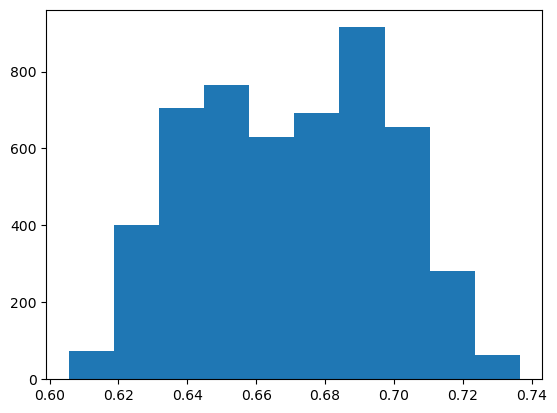

In [70]:
predictions = regression_model.predict(X)

plt.hist(x = predictions)


# <span style="color:darkblue"> V. Try it yourself

<font size = 5>

Create your own "customanalysis" class.

<font size = 3>

- Initiate the class by storing an attribute called $variables$ <br>
(the use the specialized function name )
- Create a function for that class that called ``10describe'' <br>
that computes  descriptive statistics for "variables" <br>
using ```describe()``` function to it and multiplies the resulting numbers by 10. 

<font size = 5>

Create two instances of this class for $X$ and $y$, and apply "10describe" <br>
to each of them as a self-referential function.


In [ ]:
# Write your own code






